## Importing libraries

In [1]:
import pandas as pd
import seaborn as sns

## Opening file

In [2]:
# Open the csv file and show the first 5 rows
# ACPriceDF stands for Aircraft Price Data Frame
ACPriceDF = pd.read_csv("source/Plane Price.csv")
ACPriceDF.head(5)

,Model Name,Engine Type,HP or lbs thr ea engine,Max speed Knots,Rcmnd cruise Knots,Stall Knots dirty,Fuel gal/lbs,All eng rate of climb,Eng out rate of climb,Takeoff over 50ft,Landing over 50ft,Empty weight lbs,Length ft/in,Wing span ft/in,Range N.M.,Price
0,100 Darter (S.L. Industries),Piston,145,104,91.0,46.0,36,450,900.0,1300.0,"2,050","1,180",25/3,37/5,370,1300000.0
1,7 CCM Champ,Piston,85,89,83.0,44.0,15,600,720.0,800.0,"1,350",820,20/7,36/1,190,1230000.0
2,100 Darter (S.L. Industries),Piston,90,90,78.0,37.0,19,650,475.0,850.0,"1,300",810,21/5,35/0,210,1600000.0
3,7 AC Champ,Piston,85,88,78.0,37.0,19,620,500.0,850.0,"1,300",800,21/5,35/0,210,1300000.0
4,100 Darter (S.L. Industries),Piston,65,83,74.0,33.0,14,370,632.0,885.0,"1,220",740,21/5,35/0,175,1250000.0


## File information

In [3]:
# File dimensions (x, y)
ACPriceDF.shape

(517, 16)

In [4]:
# Column data type information
ACPriceDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Model Name               517 non-null    object 
 1   Engine Type              517 non-null    object 
 2   HP or lbs thr ea engine  517 non-null    object 
 3   Max speed Knots          497 non-null    object 
 4   Rcmnd cruise Knots       507 non-null    float64
 5   Stall Knots dirty        502 non-null    float64
 6   Fuel gal/lbs             517 non-null    int64  
 7   All eng rate of climb    513 non-null    object 
 8   Eng out rate of climb    491 non-null    float64
 9   Takeoff over 50ft        492 non-null    float64
 10  Landing over 50ft        517 non-null    object 
 11  Empty weight lbs         516 non-null    object 
 12  Length ft/in             517 non-null    object 
 13  Wing span ft/in          517 non-null    object 
 14  Range N.M.               4

In [5]:
# Counting the engine type distribuition
ACPriceDF["Engine Type"].value_counts()

Engine Type
Piston     384
Jet         74
Propjet     58
piston       1
Name: count, dtype: int64

In [6]:
# Average price
ACPriceDF.describe()

,Rcmnd cruise Knots,Stall Knots dirty,Fuel gal/lbs,Eng out rate of climb,Takeoff over 50ft,Price
count,507.000000,502.000000,517.000000,491.000000,492.000000,5.070000e+02
mean,200.792899,60.795817,1419.379110,2065.126273,1743.306911,2.362673e+06
std,104.280532,16.657002,4278.320773,1150.031899,730.009674,1.018731e+06
min,70.000000,27.000000,12.000000,457.000000,500.000000,6.500000e+05
25%,130.000000,50.000000,50.000000,1350.000000,1265.000000,1.600000e+06
50%,169.000000,56.000000,89.000000,1706.000000,1525.000000,2.000000e+06
75%,232.000000,73.000000,335.000000,2357.000000,2145.750000,2.950000e+06
max,511.000000,115.000000,41000.000000,6400.000000,4850.000000,5.100000e+06


In [7]:
# Looking for missing information
ACPriceDF.isnull().sum()

Model Name                  0
Engine Type                 0
HP or lbs thr ea engine     0
Max speed Knots            20
Rcmnd cruise Knots         10
Stall Knots dirty          15
Fuel gal/lbs                0
All eng rate of climb       4
Eng out rate of climb      26
Takeoff over 50ft          25
Landing over 50ft           0
Empty weight lbs            1
Length ft/in                0
Wing span ft/in             0
Range N.M.                 18
Price                      10
dtype: int64

## Data Cleaning

In [8]:
# Deleting rows were there is missing information
ACPriceDF.dropna(inplace = True)
ACPriceDF.isnull().sum()

Model Name                 0
Engine Type                0
HP or lbs thr ea engine    0
Max speed Knots            0
Rcmnd cruise Knots         0
Stall Knots dirty          0
Fuel gal/lbs               0
All eng rate of climb      0
Eng out rate of climb      0
Takeoff over 50ft          0
Landing over 50ft          0
Empty weight lbs           0
Length ft/in               0
Wing span ft/in            0
Range N.M.                 0
Price                      0
dtype: int64

In [9]:
# Deleting a wrong input line
ACPriceDF = ACPriceDF[~ACPriceDF["Engine Type"].str.contains("piston", case=True, na=False)]
ACPriceDF["Engine Type"].value_counts()

Engine Type
Piston     334
Jet         47
Propjet     39
Name: count, dtype: int64

## Data Conversion

In [10]:
# Data Conversion - HP or lbs thr ea engine - Object to int
ACPriceDF["HP or lbs thr ea engine"] = ACPriceDF["HP or lbs thr ea engine"].str.replace(",", "").str.replace("wet", "").str.replace("dry", "").apply(eval)
ACPriceDF["HP or lbs thr ea engine"].astype(int)
# Data Conversion - Max speed Knots - Object to int
ACPriceDF["Max speed Knots"] = ACPriceDF["Max speed Knots"].str.replace("Mach", "*666.739").apply(eval)
ACPriceDF["Max speed Knots"].astype(int)
# Data Conversion - All eng rate of climb - Object to int
ACPriceDF["All eng rate of climb"] = ACPriceDF["All eng rate of climb"].str.replace(",", "").str.replace("w/3bld", "").apply(eval)
ACPriceDF["All eng rate of climb"].astype(int)

0       450
1       600
2       650
3       620
4       370
       ... 
511    1680
513    2380
514    2236
515    1750
516    2710
Name: All eng rate of climb, Length: 420, dtype: int64

In [11]:
# Creating a new Data Frame to convert the engine type to a column
newACPriceDF = pd.concat([ACPriceDF.drop("Engine Type", axis = 1), (pd.get_dummies(ACPriceDF["Engine Type"]))], axis = 1)

## Data Visualization

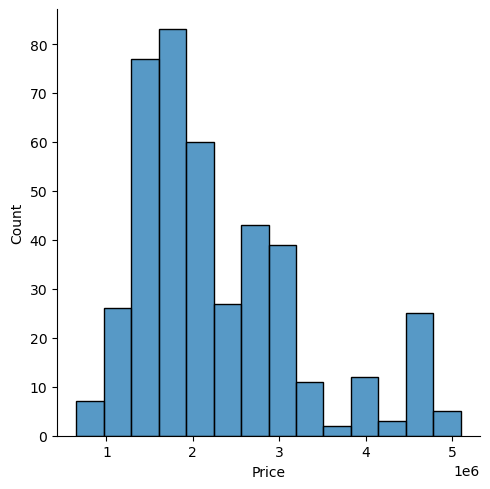

In [12]:
# Price distribuition per quantity
sns.displot(newACPriceDF["Price"])

<Axes: >

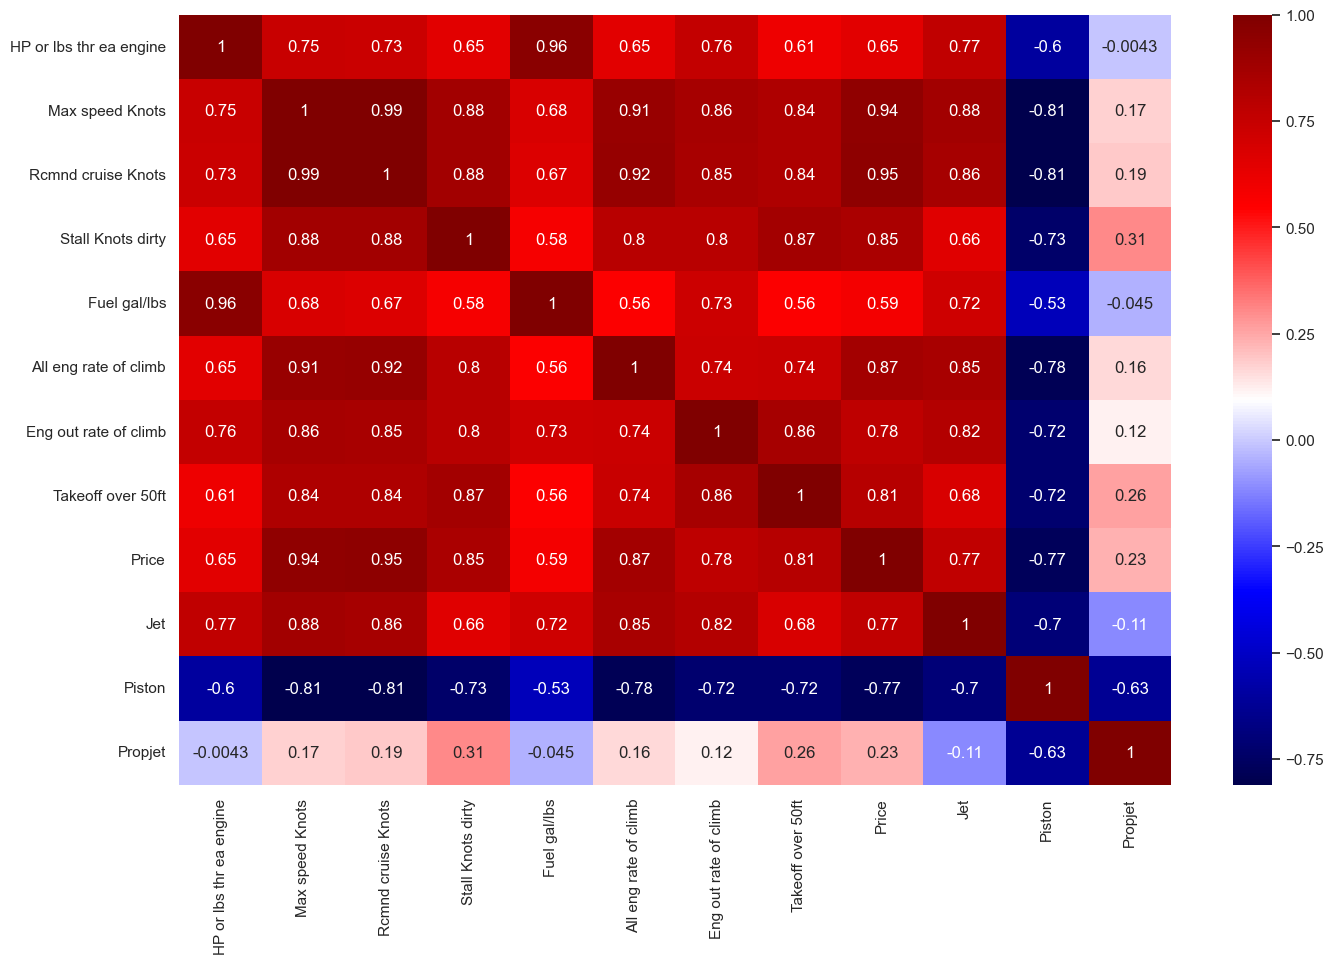

In [13]:
# Correlation between different aircraft characteristics
sns.set_theme(rc = {"figure.figsize":(16, 10)})
sns.heatmap(newACPriceDF.corr(numeric_only = True), annot = True, cmap = "seismic")